# 02 — Profit Analysis
Profitability deep-dive: margin by category, sub-category, region, and loss-making orders.


In [8]:
from pyhive import hive
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# ── Global style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = sns.color_palette("muted")

def get_conn():
    return hive.connect(host="hive-server2", port=10000,
                        database="default", auth="NONE")

def fetch_df(cur, sql):
    cur.execute(sql)
    cols = [d[0].split(".")[-1] for d in cur.description]
    return pd.DataFrame(cur.fetchall(), columns=cols)

def fmt_usd(v):
    if abs(v) >= 1_000_000:
        return f"${v/1_000_000:.2f}M"
    if abs(v) >= 1_000:
        return f"${v/1_000:.1f}K"
    return f"${v:.0f}"

conn = get_conn()
cur  = conn.cursor()
print("Connected.")


Connected.


/tmp/ipykernel_1557/3119705230.py:44: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1557/3119705230.py:44: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout()


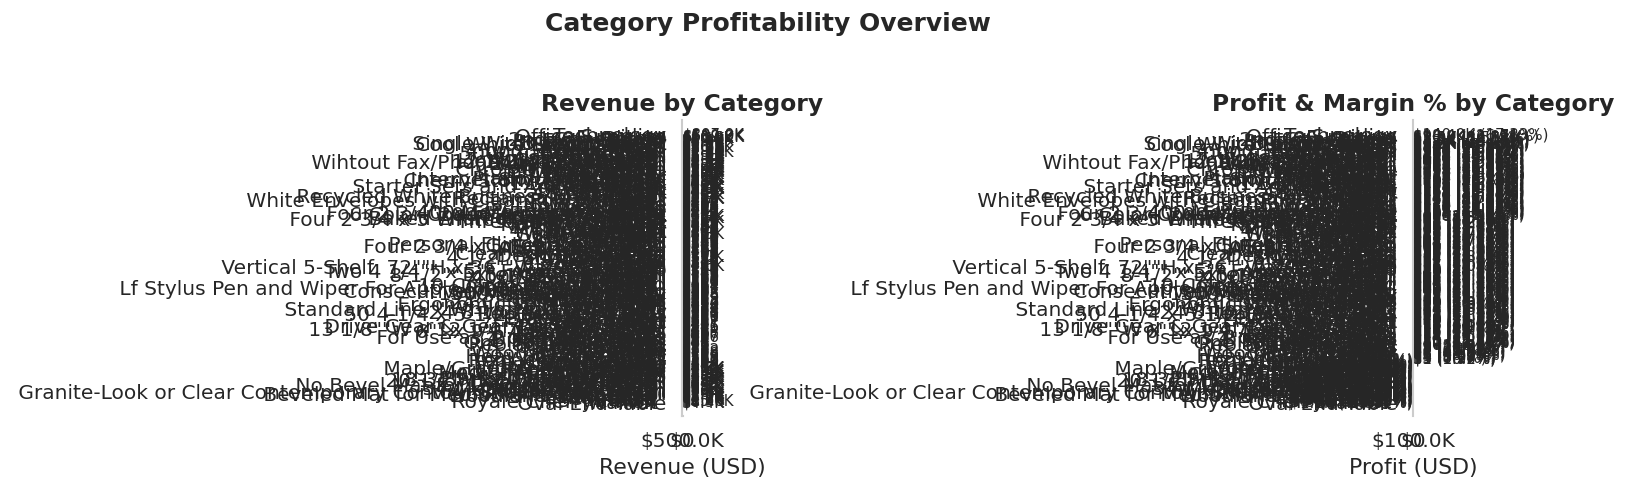

In [9]:
# ── Profit Margin by Category ─────────────────────────────────────────────────
cat_profit = fetch_df(cur, """
    SELECT p.category,
           ROUND(SUM(oi.sales),2)   AS revenue,
           ROUND(SUM(oi.profit),2)  AS profit,
           ROUND(SUM(oi.profit)/SUM(oi.sales)*100,2) AS margin_pct
    FROM order_items oi JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.category ORDER BY profit DESC
""")

colors = [PALETTE[1] if x >= 0 else PALETTE[3] for x in cat_profit["profit"]]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Category Profitability Overview", fontsize=15,
             fontweight="bold", y=1.02)

# Left: Revenue bars
axes[0].barh(cat_profit["category"][::-1], cat_profit["revenue"][::-1],
             color=PALETTE[0], edgecolor="white")
for i, val in enumerate(cat_profit["revenue"][::-1]):
    axes[0].text(val + 500, i, fmt_usd(val), va="center", fontsize=9)
axes[0].set_title("Revenue by Category")
axes[0].set_xlabel("Revenue (USD)")
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: fmt_usd(v)))
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

# Right: Profit bars with margin labels
axes[1].barh(cat_profit["category"][::-1], cat_profit["profit"][::-1],
             color=colors[::-1], edgecolor="white")
axes[1].axvline(0, color="grey", linewidth=0.8)
for i, (profit, margin) in enumerate(zip(cat_profit["profit"][::-1],
                                         cat_profit["margin_pct"][::-1])):
    offset = 200 if profit >= 0 else -200
    align  = "left" if profit >= 0 else "right"
    axes[1].text(profit + offset, i,
                 f"{fmt_usd(profit)} ({margin}%)",
                 va="center", fontsize=9, ha=align)
axes[1].set_title("Profit & Margin % by Category")
axes[1].set_xlabel("Profit (USD)")
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda v, _: fmt_usd(v)))
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


In [ ]:
# ── Profit by Sub-Category ────────────────────────────────────────────────────
sub = fetch_df(cur, """
    SELECT p.sub_category,
           ROUND(SUM(oi.profit),2) AS profit,
           ROUND(SUM(oi.profit)/SUM(oi.sales)*100,2) AS margin_pct
    FROM order_items oi JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.sub_category ORDER BY profit ASC
""")

colors = [PALETTE[1] if x >= 0 else PALETTE[3] for x in sub["profit"]]
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(sub["sub_category"], sub["profit"],
               color=colors, edgecolor="white", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=1, linestyle="--")

for bar, margin in zip(bars, sub["margin_pct"]):
    w      = bar.get_width()
    offset = 80 if w >= 0 else -80
    align  = "left" if w >= 0 else "right"
    ax.text(w + offset, bar.get_y() + bar.get_height()/2,
            f"{fmt_usd(w)}  ({margin}%)",
            va="center", ha=align, fontsize=8)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt_usd(v)))
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_xlabel("Profit (USD)")
ax.set_title("Profit & Margin % by Sub-Category", pad=12)
plt.tight_layout()
plt.show()


In [ ]:
# ── Top 20 Loss-Making Line Items ─────────────────────────────────────────────
losses = fetch_df(cur, """
    SELECT oi.order_id, p.category, p.sub_category,
           ROUND(oi.sales,2)        AS sales,
           ROUND(oi.profit,2)       AS profit,
           ROUND(oi.discount*100,1) AS discount_pct
    FROM order_items oi JOIN products p ON oi.product_id = p.product_id
    WHERE oi.profit < 0
    ORDER BY oi.profit ASC
    LIMIT 20
""")

# Bar chart: loss concentration per sub-category
loss_by_sub = losses.groupby("sub_category")["profit"].sum().sort_values()
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(loss_by_sub.index, loss_by_sub.values,
               color=PALETTE[3], edgecolor="white")
for bar in bars:
    ax.text(bar.get_width() - 30,
            bar.get_y() + bar.get_height()/2,
            fmt_usd(bar.get_width()),
            va="center", ha="right", fontsize=9,
            color="white", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: fmt_usd(v)))
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.set_xlabel("Total Loss (USD)")
ax.set_title("Loss Concentration by Sub-Category (sampled top 20)")
plt.tight_layout()
plt.show()


In [ ]:
cur.close()
conn.close()
print("Done.")
